In [10]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [11]:
total_keys2 = ["L_MASS",'Lb_MASS','Jpsi_MASS','Jpsi_P', "Jpsi_PT",'Jpsi_CHI2','Jpsi_MAXDOCA','Jpsi_BPVDIRA','Jpsi_END_VRHO','Jpsi_END_VX','Jpsi_END_VY','Jpsi_END_VZ','Jpsi_BPVIP','Jpsi_MINIPCHI2','L_P','L_PT','L_PX','L_PY','L_PZ','L_CHI2',
               'L_END_VZ','L_END_VX','L_END_VY',"L_END_VRHO","L_BPVDIRA","L_BPVIP","L_BPVIPCHI2",'L_BPVFDCHI2','L_MINIPCHI2',"Lb_P","Lb_PT",'Lb_PX','Lb_PY','Lb_PZ',"Lb_CHI2","Lb_MAXDOCA","Lb_BPVDIRA","Lb_BPVVDRHO",
               "Lb_BPVIP",'Lb_BPVIPCHI2','Lb_BPVFDCHI2','Lb_MINIPCHI2',"p_P","p_PT",'p_PX','p_PY','p_PZ',"p_PID_P",
               "p_PID_K","p_MINIP",'p_GHOSTPROB',"pim_P","pim_PT",'pim_PX','pim_PY','pim_PZ','pim_GHOSTPROB','mum_P','mum_PT','mum_PX','mum_PY','mum_PZ','mum_CHI2','mum_GHOSTPROB','mum_PID_P','mum_PID_K','mum_PID_MU',
               'mum_PID_E','mum_MINIP','mum_MINIPCHI2','mup_P','mup_PT','mup_PX','mup_PY','mup_PZ','mup_CHI2','mup_GHOSTPROB','mup_PID_P','mup_PID_K','mup_PID_MU','mup_PID_E','mup_MINIP','mup_MINIPCHI2',
               'totCandidates','p_TRUEORIGIN_VZ', 'Lb_ETA', 'Jpsi_ETA', 'p_ETA', 'pim_ETA']

In [12]:
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

In [13]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data2 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data3 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data4 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_data5 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data6 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data7 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data8 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")


mc_background = mc_background_merge.query(preselection_cut_mc)

mc_data_preselection = mc_signal_background_merge.query(preselection_cut_mc)
mc_data = mc_signal_background_merge
mc_signal = mc_signal_merge

In [14]:
#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
angle = np.arccos((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_angle = ((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Theta_P'] = angle
mc_signal['Cos_theta_P'] = cos_angle
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_LbP
mc_signal['xi_LbP'] = xi_LP

mc_signal_preselection = mc_signal.query(preselection_cut_mc)

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_19813/3576386377.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_19813/3576386377.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['Theta_P'] = angle
/tmp/javeser/ipykernel_19813/3576386377.py:13: PerformanceWarning: DataFrame is highly fragmented.  T

In [15]:
signal_data = pd.read_pickle('data24_armenteros.pkl')
signal_data = pd.read_pickle('data24_armenteros.pkl')
adding_data = pd.read_pickle('data24_armenteros_add.pkl')
signal_data = pd.concat([signal_data,adding_data],axis='columns')
#Creates a new variables like the Cos()...
sum_CHI2 = signal_data['Lb_CHI2']+signal_data['L_CHI2']+signal_data['Jpsi_CHI2']
angle = np.arccos((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_angle = ((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_xi_L = ((signal_data['p_PX']*signal_data['L_PX']+signal_data['p_PY']*signal_data['L_PY']+signal_data['p_PZ']*signal_data['L_PZ'])/(signal_data['p_P']*signal_data['L_P']))
cos_xi_Lb = ((signal_data['p_PX']*signal_data['Lb_PX']+signal_data['p_PY']*signal_data['Lb_PY']+signal_data['p_PZ']*signal_data['Lb_PZ'])/(signal_data['p_P']*signal_data['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
signal_data['SUMCHI2'] = sum_CHI2
signal_data['Theta_P'] = angle
signal_data['Cos_theta_P'] = cos_angle
signal_data['Cos_xi_LP'] = cos_xi_L
signal_data['Cos_xi_LbP'] = cos_xi_Lb
signal_data['xi_LP'] = xi_LbP
signal_data['xi_LbP'] = xi_LP


signal_data

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_ETA,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,...,pim_TRACK_POS_CLOSESTTOBEAM_X,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z,SUMCHI2,Theta_P,Cos_theta_P,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP
0,1077.975830,5846.956055,2974.502686,54863.386719,1776.397949,4.123077,0.005935,0.002314,0.997817,1.207904,...,-1746.7484,-215.8711,7895.8999,1.332619,0.140961,0.990081,0.999991,0.999902,0.014029,0.004257
1,1077.976562,5313.719238,3112.583496,58726.832031,1343.211792,4.470844,0.122067,0.009861,0.997888,1.222700,...,-1700.6754,505.1554,7826.0996,1.834390,0.127805,0.991844,0.999985,0.999979,0.006496,0.005426
2,1078.187256,6402.193359,3093.716309,18753.294922,2738.893555,2.611505,0.071255,0.009010,0.984698,1.317595,...,-1685.1663,-605.9817,7826.0996,8.643069,0.336862,0.943797,0.999327,0.999409,0.034373,0.036701
3,1078.331421,5060.589355,3078.505615,36252.464844,492.338257,4.992107,1.107087,0.028151,0.996496,1.103896,...,-1684.7295,-23.0286,7826.0996,24.885163,0.171750,0.985287,0.999998,0.999966,0.008250,0.002072
4,1078.344971,5300.834473,2953.872803,26179.085938,1636.410034,3.464616,1.147581,0.034740,0.992858,1.206773,...,-1658.7753,-189.1307,7895.8999,5.839044,0.227141,0.974314,1.000000,0.999871,0.016058,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2385520,1499.999146,5465.837891,3116.906006,68869.664062,1651.937012,4.423246,0.240755,0.012574,0.999810,1.170818,...,1605.0896,-302.4525,7895.8994,37.424356,0.094939,0.995497,0.999515,0.999125,0.041827,0.031148
2385521,1499.999268,5057.749512,3105.656494,37938.269531,3193.528564,3.166201,2.272352,0.042266,0.986553,1.228708,...,1619.1001,225.9496,7826.0991,23.769515,0.165611,0.986318,0.999625,0.994184,0.107904,0.027388
2385522,1499.999634,6379.979980,3111.542480,38214.558594,2022.875732,3.631062,2.339109,0.063037,0.997769,1.338594,...,1627.0600,429.3525,7826.0991,42.082629,0.162117,0.986888,0.999794,0.997756,0.067000,0.020283
2385523,1499.999756,6493.334473,3065.772461,27737.134766,2734.924072,3.007334,0.421790,0.024650,0.999892,1.357072,...,1807.2089,-422.2669,7826.0991,26.433014,0.223562,0.975114,0.999879,0.999713,0.023974,0.015564


In [16]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(signal_data)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
signal_data['prob1'] = signal_MVA_probs

[[9.70173569e-01 2.98264308e-02]
 [9.93784746e-01 6.21525380e-03]
 [9.99656795e-01 3.43205462e-04]
 ...
 [9.99999133e-01 8.67161421e-07]
 [9.99999999e-01 1.38281954e-09]
 [9.99744382e-01 2.55617832e-04]]


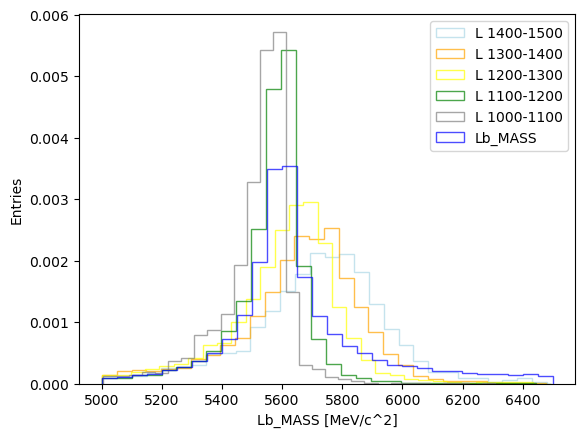

In [22]:


# Create the figure and axes
fig, axes = plt.subplots()
density = 'True'
num_bins = 30
# Plot histograms
hist1, bins1, _ = axes.hist(mc_signal.query('(L_MASS >1400 )&(L_MASS < 1500)')['Lb_MASS'], bins=num_bins, label='L 1400-1500', color='lightblue', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(mc_signal.query('(L_MASS >1300 )&(L_MASS < 1400)')['Lb_MASS'], bins=num_bins, label='L 1300-1400', color='orange', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(mc_signal.query('(L_MASS >1200 )&(L_MASS < 1300)')['Lb_MASS'], bins=num_bins, label='L 1200-1300', color='yellow', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(mc_signal.query('(L_MASS >1100 )&(L_MASS < 1200)')['Lb_MASS'], bins=num_bins, label='L 1100-1200', color='green', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(mc_signal.query('(L_MASS >1000 )&(L_MASS < 1100)')['Lb_MASS'], bins=num_bins, label='L 1000-1100', color='grey', alpha=0.7, histtype='step', density=density)
hist2, bins2, _ = axes.hist(mc_signal['Lb_MASS'], bins=num_bins, label='Lb_MASS', color='blue', alpha=0.7, histtype='step', density=density)
# hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


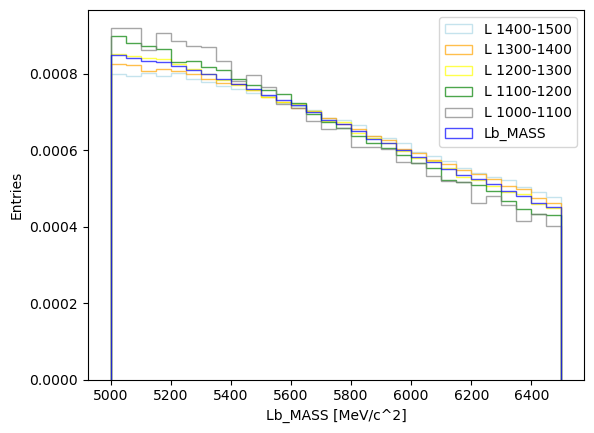

In [23]:


# Create the figure and axes
fig, axes = plt.subplots()
density = 'True'
num_bins = 30
# Plot histograms
hist1, bins1, _ = axes.hist(signal_data.query('(L_MASS >1400 )&(L_MASS < 1500)')['Lb_MASS'], bins=num_bins, label='L 1400-1500', color='lightblue', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(L_MASS >1300 )&(L_MASS < 1400)')['Lb_MASS'], bins=num_bins, label='L 1300-1400', color='orange', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(L_MASS >1200 )&(L_MASS < 1300)')['Lb_MASS'], bins=num_bins, label='L 1200-1300', color='yellow', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(L_MASS >1100 )&(L_MASS < 1200)')['Lb_MASS'], bins=num_bins, label='L 1100-1200', color='green', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(L_MASS >1000 )&(L_MASS < 1100)')['Lb_MASS'], bins=num_bins, label='L 1000-1100', color='grey', alpha=0.7, histtype='step', density=density)
hist2, bins2, _ = axes.hist(signal_data['Lb_MASS'], bins=num_bins, label='Lb_MASS', color='blue', alpha=0.7, histtype='step', density=density)
# hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


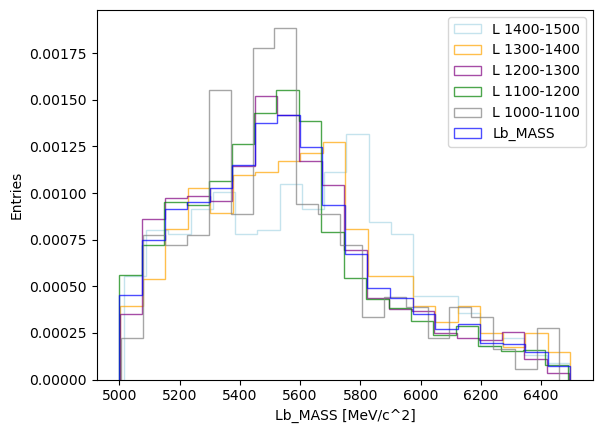

In [42]:


# Create the figure and axes
fig, axes = plt.subplots()
density = 'True'
num_bins = 20
# Plot histograms
hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0.95)&(L_MASS >1400 )&(L_MASS < 1500)')['Lb_MASS'], bins=num_bins, label='L 1400-1500', color='lightblue', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0.95)&(L_MASS >1300 )&(L_MASS < 1400)')['Lb_MASS'], bins=num_bins, label='L 1300-1400', color='orange', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0.95)&(L_MASS >1200 )&(L_MASS < 1300)')['Lb_MASS'], bins=num_bins, label='L 1200-1300', color='purple', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0.95)&(L_MASS >1100 )&(L_MASS < 1200)')['Lb_MASS'], bins=num_bins, label='L 1100-1200', color='green', alpha=0.7, histtype='step', density=density)
hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0.95)&(L_MASS >1000 )&(L_MASS < 1100)')['Lb_MASS'], bins=num_bins, label='L 1000-1100', color='grey', alpha=0.7, histtype='step', density=density)
hist2, bins2, _ = axes.hist(signal_data.query('(prob1 > 0.95)')['Lb_MASS'], bins=num_bins, label='Lb_MASS', color='blue', alpha=0.7, histtype='step', density=density)
# hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()
